In [1]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
time_steps = 70
spectral_radius = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=1
fixed_whh=False
fixed_wih=False

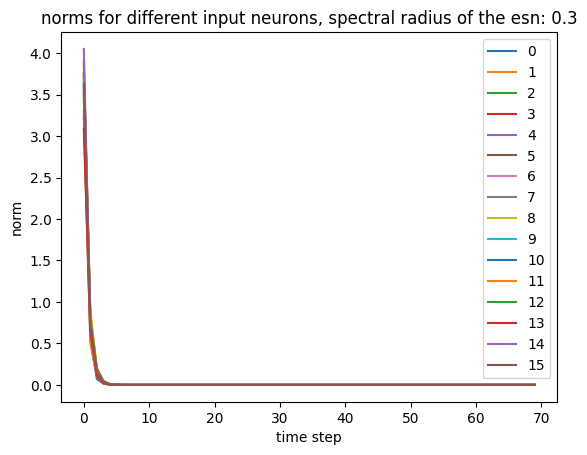

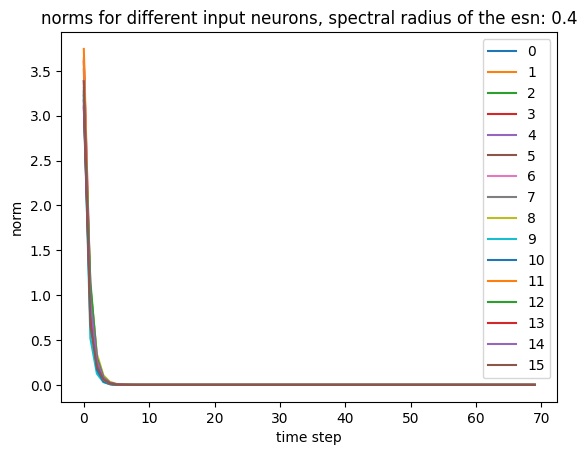

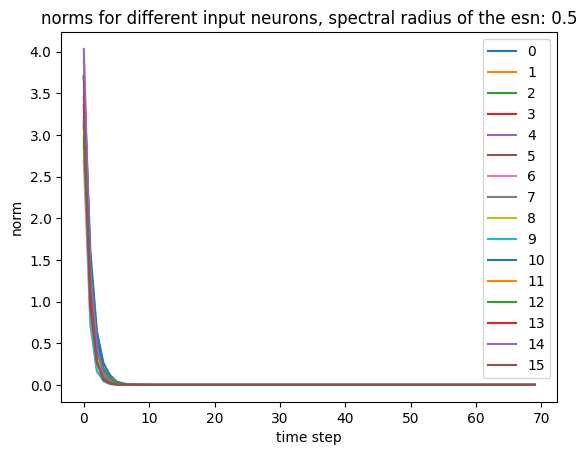

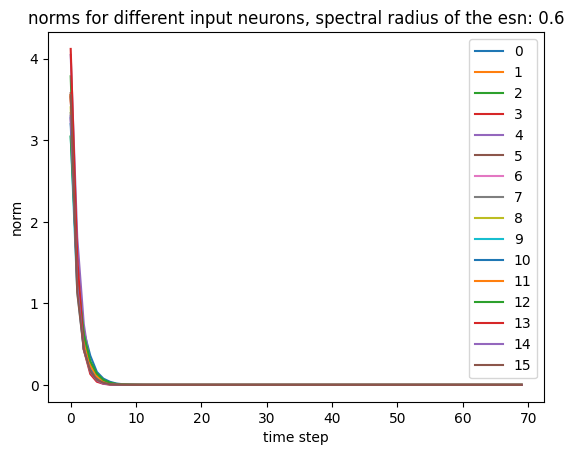

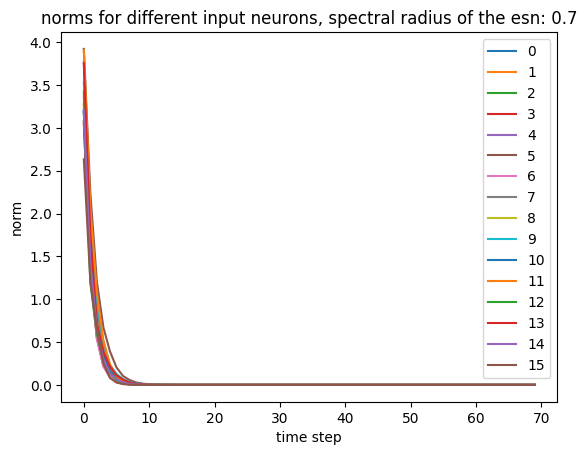

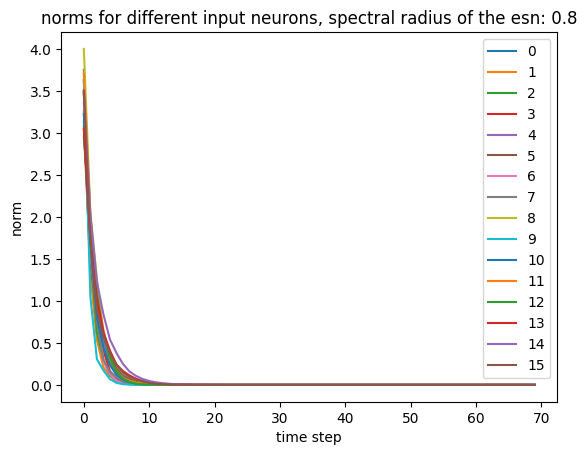

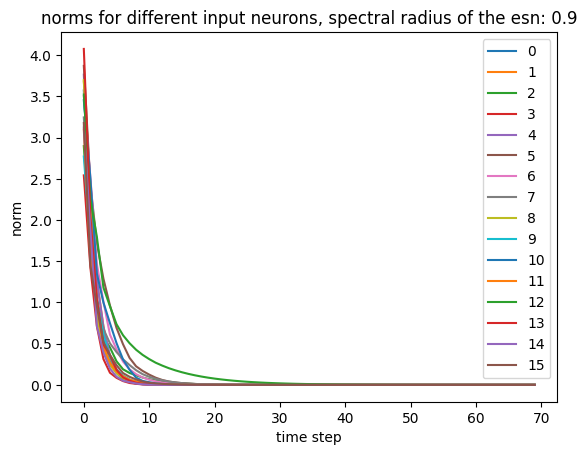

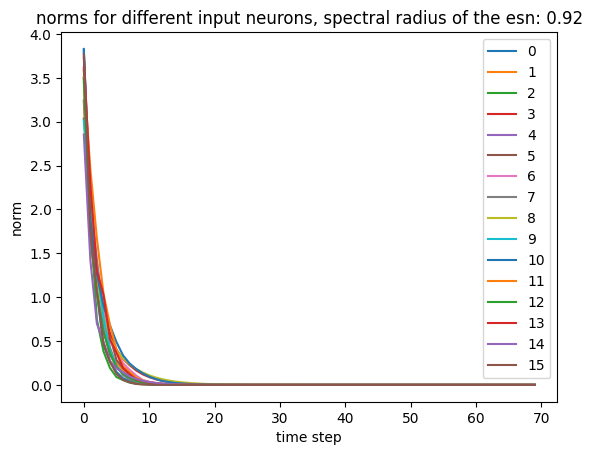

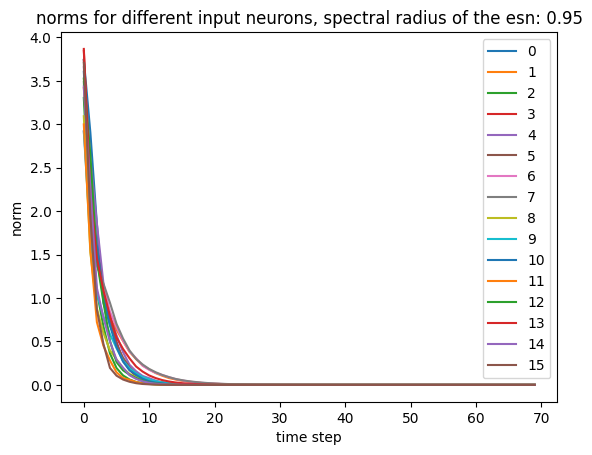

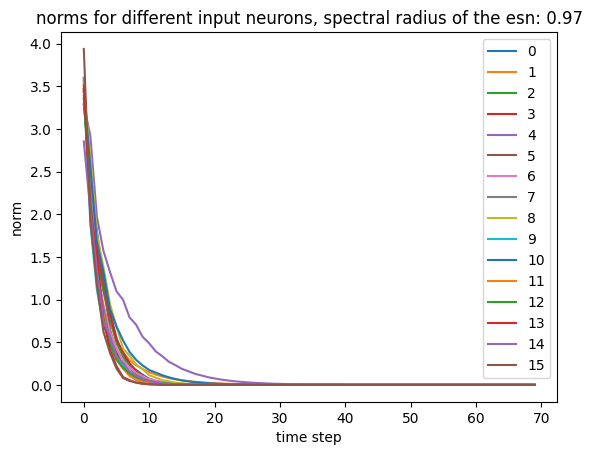

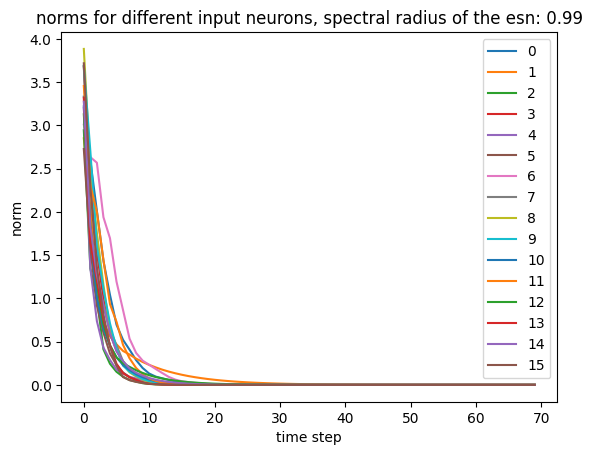

In [3]:
# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    plt.figure()
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        norms = hs.norm(dim=1)
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        plt.plot(norms, label=f'{i}')
    
    plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}')
    plt.xlabel('time step')
    plt.ylabel('norm')
    plt.legend()
    

     

In [4]:
# define a threshold and see at which time step the norms cross the threshold
# with this you can see at which time step there is basically no more information of the original input in the system

threshold = 0.05

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]
    

In [5]:
# at what time step was the threshold reached for each spectral radius - for each different feature that received a non zero input in the beginning

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.]
 [ 3.  4.  4.  3.  3.  4.  4.  4.  4.  3.  3.  4.  4.  4.  4.  4.]
 [ 5.  4.  4.  4.  5.  4.  4.  5.  4.  3.  5.  4.  5.  4.  4.  4.]
 [ 6.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  6.  4.  5.  5.]
 [ 6.  6.  5.  5.  6.  8.  5.  6.  6.  7.  6.  6.  6.  7.  6.  5.]
 [ 7.  5.  5.  6.  8.  8.  6.  6.  9.  5.  7.  7.  7.  9. 10.  9.]
 [ 7.  7. 12.  6.  7. 13. 11. 13.  8.  8.  9.  8. 24.  8.  7.  9.]
 [ 7. 10.  7. 12.  8.  9. 10.  8. 14.  9. 12.  9.  8.  9.  9.  7.]
 [11. 15.  8. 10. 11. 11. 16. 16. 10. 11. 10.  8.  9. 13.  9.  7.]
 [11. 16. 11. 11. 23.  9. 12.  9. 13.  9. 16.  9. 10.  8. 10.  7.]
 [14. 22.  8. 11. 10.  9. 15. 11. 10. 10. 11. 11. 14.  9. 12.  8.]]
[ 3.      3.6875  4.25    5.0625  6.      7.125   9.8125  9.25   10.9375
 11.5    11.5625]


In [6]:
threshold = 0.0001

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 7.  8.  8.  7.  8.  6.  7.  7.  7.  7.  6.  7.  7.  7.  7.  7.]
 [ 8.  9.  8.  7.  8.  8.  9.  9. 10.  8.  8.  8.  9.  8.  9.  9.]
 [11.  9.  9. 10. 11. 10.  9. 13. 10.  8. 12. 10. 12.  9. 10.  9.]
 [14. 12. 11. 12. 11. 11. 10. 12. 12. 14. 12. 13. 13. 10. 10. 11.]
 [13. 14. 12. 12. 15. 17. 12. 14. 14. 16. 17. 14. 13. 15. 14. 11.]
 [18. 15. 14. 15. 23. 22. 13. 15. 23. 11. 16. 19. 16. 25. 26. 23.]
 [16. 16. 34. 15. 16. 32. 28. 33. 19. 21. 20. 20. 68. 18. 16. 25.]
 [16. 23. 16. 31. 21. 22. 22. 18. 38. 20. 30. 23. 23. 23. 26. 15.]
 [26. 39. 19. 18. 26. 26. 40. 42. 28. 31. 23. 19. 23. 31. 22. 18.]
 [25. 48. 25. 26. 56. 19. 29. 21. 30. 20. 41. 23. 27. 16. 23. 18.]
 [34. 67. 20. 26. 36. 21. 34. 26. 22. 25. 29. 24. 45. 20. 33. 21.]]
[ 7.0625  8.4375 10.125  11.75   13.9375 18.375  24.8125 22.9375 26.9375
 27.9375 30.1875]
